In [1]:
!pip install kaggle imbalanced-learn xgboost shap streamlit -q


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 34.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 56.9 MB/s eta 0:00:00


In [2]:
!mkdir -p ~/.kaggle
!echo 'KGAT_be19b27d37094405c56376fff65eb16c' > ~/.kaggle/access_token
!chmod 600 ~/.kaggle/access_token


In [4]:
!kaggle datasets list

ref                                                         title                                                     size  lastUpdated                 downloadCount  voteCount  usabilityRating  
----------------------------------------------------------  --------------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
dreaddevelopment/raptor-knee-widedense                      Knee MRI model weights: twelve findings              543320725  2026-08-23 04:12:20.703000            996         61  0.9375           
datascikhan/e-commerce-sales-and-customer-analytics         E-Commerce Sales Analytics Dataset                    29815424  2026-08-25 08:00:46.013000           4215        100  1                
erfan4524/e-commerce-sales-data-analysis-and-eda            E-Commerce Sales Data Analysis & EDA                   2209495  2026-08-28 15:12:17.040000           3118         67  1                
srisyra02/online-foo

In [5]:
!kaggle datasets download -d mlg-ulb/creditcardfraud
!unzip -q creditcardfraud.zip

Dataset URL: https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud
License(s): DbCL-1.0
100% 66.0M/66.0M [00:03<00:00, 18.8MB/s]



In [6]:
!unzip -q creditcardfraud.zip

replace creditcard.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y


In [8]:
!unzip -o -q creditcardfraud.zip


In [9]:
import pandas as pd

df = pd.read_csv('creditcard.csv')
print(df.shape)
print(df['Class'].value_counts())
print(df['Class'].value_counts(normalize=True) * 100)
df.head()


(284807, 31)
Class
0    284315
1       492
Name: count, dtype: int64
Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')

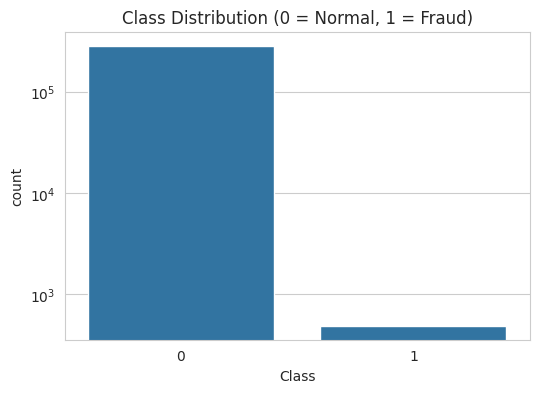

In [11]:
plt.figure(figsize=(6,4))
sns.countplot(x='Class', data=df)
plt.title('Class Distribution (0 = Normal, 1 = Fraud)')
plt.yscale('log')  # log scale because fraud count is so tiny it'd be invisible otherwise
plt.show()


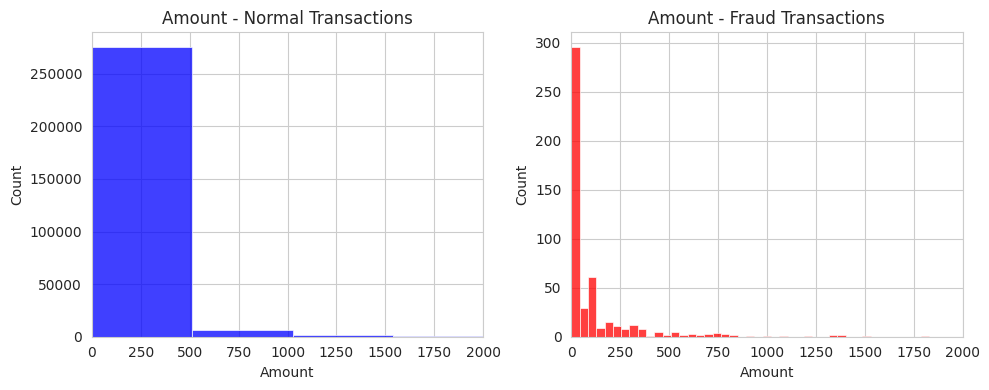

In [12]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
sns.histplot(df[df['Class']==0]['Amount'], bins=50, color='blue')
plt.title('Amount - Normal Transactions')
plt.xlim(0,2000)

plt.subplot(1,2,2)
sns.histplot(df[df['Class']==1]['Amount'], bins=50, color='red')
plt.title('Amount - Fraud Transactions')
plt.xlim(0,2000)

plt.tight_layout()
plt.show()

In [13]:
print("Normal transactions - Amount stats:")
print(df[df['Class']==0]['Amount'].describe())
print("\nFraud transactions - Amount stats:")
print(df[df['Class']==1]['Amount'].describe())

Normal transactions - Amount stats:
count    284315.000000
mean         88.291022
std         250.105092
min           0.000000
25%           5.650000
50%          22.000000
75%          77.050000
max       25691.160000
Name: Amount, dtype: float64

Fraud transactions - Amount stats:
count     492.000000
mean      122.211321
std       256.683288
min         0.000000
25%         1.000000
50%         9.250000
75%       105.890000
max      2125.870000
Name: Amount, dtype: float64


In [14]:
from sklearn.model_selection import train_test_split

X = df.drop('Class', axis=1)
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Fraud in train:", y_train.sum())
print("Fraud in test:", y_test.sum())

Train shape: (227845, 30)
Test shape: (56962, 30)
Fraud in train: 394
Fraud in test: 98


In [15]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", y_train.value_counts())
print("\nAfter SMOTE:", y_train_smote.value_counts())


Before SMOTE: Class
0    227451
1       394
Name: count, dtype: int64

After SMOTE: Class
0    227451
1    227451
Name: count, dtype: int64


In [16]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_smote, y_train_smote)

y_pred_lr = lr.predict(X_test)

print("Logistic Regression Results:")
print(classification_report(y_test, y_pred_lr))
print("ROC-AUC:", roc_auc_score(y_test, lr.predict_proba(X_test)[:,1]))

Logistic Regression Results:
              precision    recall  f1-score   support

           0       1.00      0.99      0.99     56864
           1       0.12      0.90      0.21        98

    accuracy                           0.99     56962
   macro avg       0.56      0.94      0.60     56962
weighted avg       1.00      0.99      0.99     56962

ROC-AUC: 0.9759745414766919


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [17]:
from xgboost import XGBClassifier

xgb = XGBClassifier(random_state=42, eval_metric='logloss')
xgb.fit(X_train_smote, y_train_smote)

y_pred_xgb = xgb.predict(X_test)

print("XGBoost Results:")
print(classification_report(y_test, y_pred_xgb))
print("ROC-AUC:", roc_auc_score(y_test, xgb.predict_proba(X_test)[:,1]))

XGBoost Results:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.77      0.86      0.81        98

    accuracy                           1.00     56962
   macro avg       0.89      0.93      0.91     56962
weighted avg       1.00      1.00      1.00     56962

ROC-AUC: 0.9829774657471317


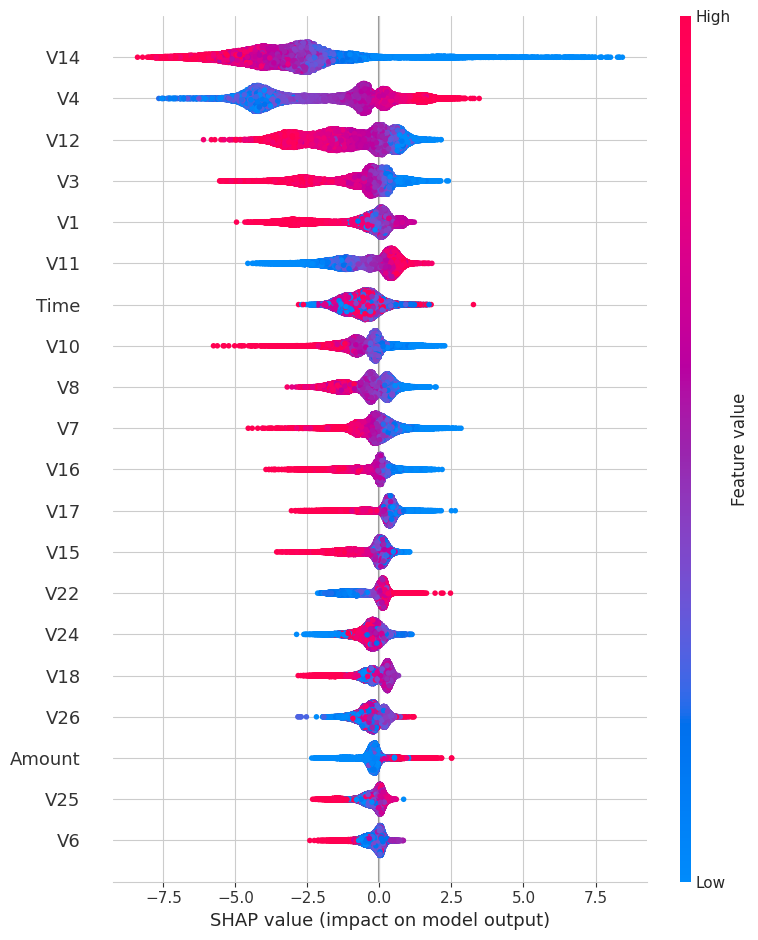

In [18]:
import shap

explainer = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test)

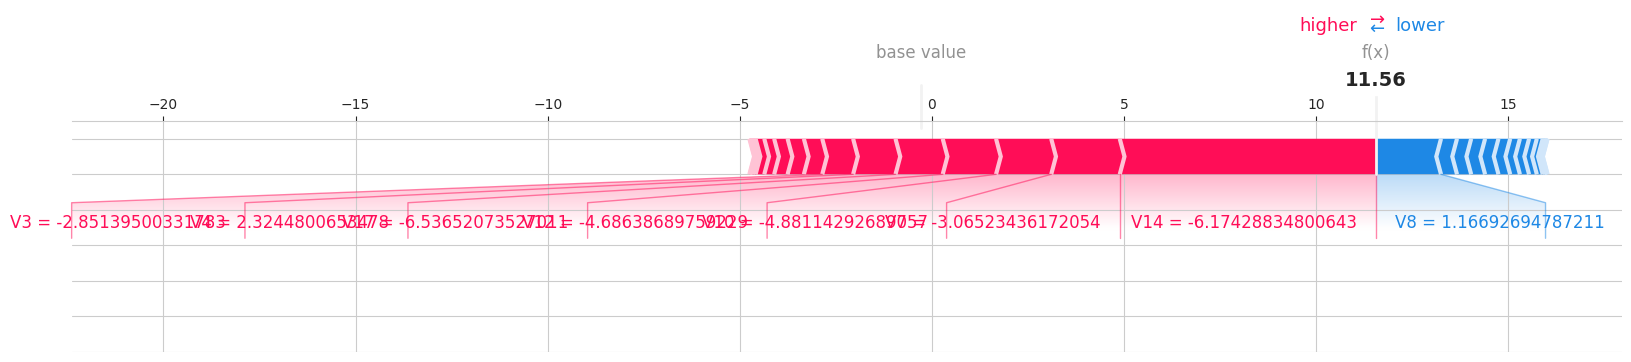

In [19]:
# Pick one fraud case from test set and explain that specific prediction
fraud_idx = y_test[y_test==1].index[0]
idx_pos = X_test.index.get_loc(fraud_idx)

shap.force_plot(explainer.expected_value, shap_values[idx_pos], X_test.iloc[idx_pos], matplotlib=True)

In [20]:
!pip install pyngrok -q


In [21]:
import joblib

joblib.dump(xgb, 'fraud_model.pkl')
print("Model saved!")

Model saved!


In [22]:
%%writefile app.py
import streamlit as st
import pandas as pd
import joblib
import shap
import matplotlib.pyplot as plt

st.title("💳 Fraud Detection Demo")
st.write("Upload transaction data or enter values manually to check fraud probability.")

model = joblib.load('fraud_model.pkl')

uploaded_file = st.file_uploader("Upload a CSV of transactions", type="csv")

if uploaded_file is not None:
    data = pd.read_csv(uploaded_file)
    st.write("Preview of uploaded data:", data.head())

    if st.button("Predict Fraud"):
        preds = model.predict(data)
        probs = model.predict_proba(data)[:, 1]
        data['Fraud_Prediction'] = preds
        data['Fraud_Probability'] = probs
        st.write(data[['Fraud_Prediction', 'Fraud_Probability']])

        # SHAP explanation for first row
        explainer = shap.TreeExplainer(model)
        shap_values = explainer.shap_values(data.drop(columns=['Fraud_Prediction','Fraud_Probability'], errors='ignore'))
        st.write("SHAP explanation for first transaction:")
        fig, ax = plt.subplots()
        shap.force_plot(explainer.expected_value, shap_values[0],
                         data.drop(columns=['Fraud_Prediction','Fraud_Probability'], errors='ignore').iloc[0],
                         matplotlib=True, show=False)
        st.pyplot(fig)

Writing app.py


In [23]:
from pyngrok import ngrok

ngrok.set_auth_token("3J4qbOEnPEYd9jIHSxizrz0xLQo_2oY45QUG26r8iJwbByUon")

In [24]:
import subprocess
import time

subprocess.Popen(['streamlit', 'run', 'app.py', '--server.port', '8501'])
time.sleep(5)

public_url = ngrok.connect(8501)
print("Your app is live at:", public_url)

Your app is live at: NgrokTunnel: "https://starless-track-gullible.ngrok-free.dev" -> "http://localhost:8501"


In [25]:
# Create a small sample CSV to test the app (a few rows, no Class column)
sample = X_test.iloc[:10]  # first 10 test transactions
sample.to_csv('sample_transactions.csv', index=False)
print("Sample file created — download it from the Colab file browser (folder icon on left sidebar)")

Sample file created — download it from the Colab file browser (folder icon on left sidebar)
